In [18]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder

In [23]:
# ===== IMDB =====
dataset_name = "IMDB"

train = pd.read_csv("imdb_clean_train.csv")
val = pd.read_csv("imdb_clean_val.csv")
test = pd.read_csv("imdb_clean_test.csv")

print("Train shape:", train.shape)
print("Val shape:", val.shape)
print("Test shape:", test.shape)

print(train.head())

Train shape: (34998, 3)
Val shape: (7502, 3)
Test shape: (7500, 3)
      id                                               text  label
0  33064  Now, I love bad, old skifee movies as much as ...      0
1  27663  OK, I read the director's comment about this m...      0
2  44415  Greetings again from the darkness. Mary Heron ...      1
3  40454  I don't know what it is with this movies. But ...      1
4  36287  I expected so much more than what I received f...      0


Train label counts:
label
0    17499
1    17499
Name: count, dtype: int64

Train label proportions:
label
0    0.5
1    0.5
Name: proportion, dtype: float64


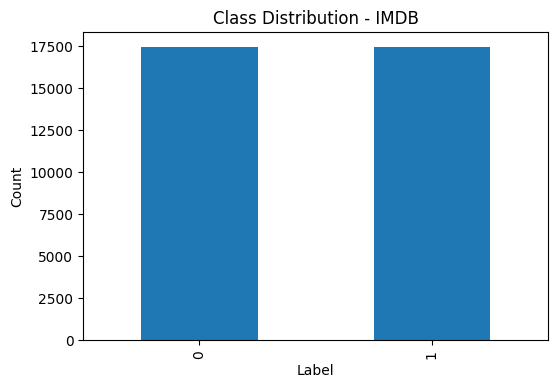

In [24]:
print("Train label counts:")
print(train["label"].value_counts().sort_index())

print("\nTrain label proportions:")
print(train["label"].value_counts(normalize=True).sort_index())

plt.figure(figsize=(6, 4))
train["label"].value_counts().sort_index().plot(kind="bar")
plt.title(f"Class Distribution - {dataset_name}")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

Train text length stats:
count    34998.000000
mean       118.912795
std         20.760288
min          4.000000
50%        128.000000
95%        128.000000
max        128.000000
Name: text_len, dtype: float64


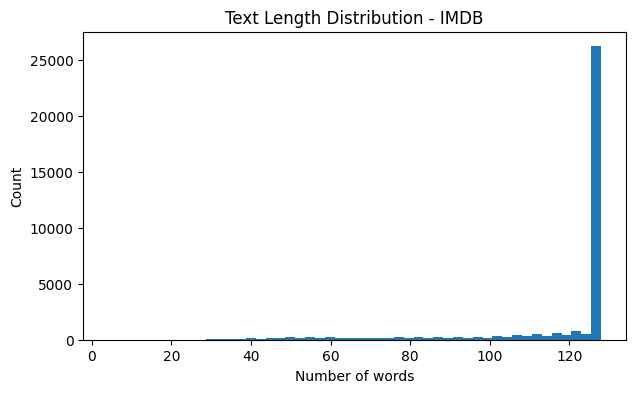

Proportion of training texts longer than 512 words: 0.0000


In [25]:
train["text_len"] = train["text"].apply(lambda x: len(x.split()))
val["text_len"] = val["text"].apply(lambda x: len(x.split()))
test["text_len"] = test["text"].apply(lambda x: len(x.split()))

print("Train text length stats:")
print(train["text_len"].describe(percentiles=[0.5, 0.95]))

plt.figure(figsize=(7, 4))
plt.hist(train["text_len"], bins=50)
plt.title(f"Text Length Distribution - {dataset_name}")
plt.xlabel("Number of words")
plt.ylabel("Count")
plt.show()

over_512 = (train["text_len"] > 512).mean()
print(f"Proportion of training texts longer than 512 words: {over_512:.4f}")

In [27]:
def stratified_subsample(df, label_col="label", frac=1.0, random_state=42):
    if frac == 1.0:
        return df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    sampled_parts = []
    for label, group in df.groupby(label_col):
        n_samples = max(1, int(len(group) * frac))
        sampled_group = group.sample(n=n_samples, random_state=random_state)
        sampled_parts.append(sampled_group)

    sampled_df = (
        pd.concat(sampled_parts)
        .sample(frac=1, random_state=random_state)
        .reset_index(drop=True)
    )
    return sampled_df

In [15]:
def run_logreg(train_df, val_df, test_df, text_col="text", label_col="label"):
    best_f1 = -1
    best_C = None
    best_max_features = None
    best_model = None
    best_vectorizer = None
    best_train_time = None

    for C in [0.1, 1, 10]:
        for max_feat in [10000, 30000, 50000]:
            vectorizer = TfidfVectorizer(
                max_features=max_feat,
                ngram_range=(1, 2)
            )

            X_train = vectorizer.fit_transform(train_df[text_col])
            X_val = vectorizer.transform(val_df[text_col])

            y_train = train_df[label_col]
            y_val = val_df[label_col]

            model = LogisticRegression(C=C, max_iter=1000)

            start_train = time.time()
            model.fit(X_train, y_train)
            train_time = time.time() - start_train

            val_preds = model.predict(X_val)
            val_f1 = f1_score(y_val, val_preds, average="macro")

            if val_f1 > best_f1:
                best_f1 = val_f1
                best_C = C
                best_max_features = max_feat
                best_model = model
                best_vectorizer = vectorizer
                best_train_time = train_time

    X_test = best_vectorizer.transform(test_df[text_col])
    y_test = test_df[label_col]

    start_infer = time.time()
    test_preds = best_model.predict(X_test)
    infer_time = time.time() - start_infer

    test_acc = accuracy_score(y_test, test_preds)
    test_macro_f1 = f1_score(y_test, test_preds, average="macro")
    cls_report = classification_report(y_test, test_preds, output_dict=True)

    return {
        "model_name": "TF-IDF + LogReg",
        "best_C": best_C,
        "best_max_features": best_max_features,
        "accuracy": test_acc,
        "macro_f1": test_macro_f1,
        "train_time": best_train_time,
        "infer_time": infer_time,
        "y_true": np.array(y_test),
        "y_pred": np.array(test_preds),
        "classification_report": cls_report
    }

In [39]:
def run_svm(train_df, val_df, test_df, text_col="text", label_col="label"):
    best_f1 = -1
    best_C = None
    best_max_features = None
    best_model = None
    best_vectorizer = None
    best_train_time = None

    for C in [0.1, 1, 10]:
        for max_feat in [10000, 30000, 50000]:

            vectorizer = TfidfVectorizer(
                max_features=max_feat,
                ngram_range=(1, 2)
            )

            X_train = vectorizer.fit_transform(train_df[text_col])
            X_val = vectorizer.transform(val_df[text_col])

            y_train = train_df[label_col]
            y_val = val_df[label_col]

            model = LinearSVC(C=C)

            start_train = time.time()
            model.fit(X_train, y_train)
            train_time = time.time() - start_train

            val_preds = model.predict(X_val)
            val_f1 = f1_score(y_val, val_preds, average="macro")

            if val_f1 > best_f1:
                best_f1 = val_f1
                best_C = C
                best_max_features = max_feat
                best_model = model
                best_vectorizer = vectorizer
                best_train_time = train_time

    X_test = best_vectorizer.transform(test_df[text_col])
    y_test = test_df[label_col]

    start_infer = time.time()
    test_preds = best_model.predict(X_test)
    infer_time = time.time() - start_infer

    test_acc = accuracy_score(y_test, test_preds)
    test_macro_f1 = f1_score(y_test, test_preds, average="macro")
    cls_report = classification_report(y_test, test_preds, output_dict=True)

    return {
        "model_name": "TF-IDF + SVM",
        "best_C": best_C,
        "best_max_features": best_max_features,
        "accuracy": test_acc,
        "macro_f1": test_macro_f1,
        "train_time": best_train_time,
        "infer_time": infer_time,
        "y_true": np.array(y_test),
        "y_pred": np.array(test_preds),
        "classification_report": cls_report
    }

In [40]:
fractions = [1.0, 0.5, 0.25, 0.1, 0.05, 0.01]
seeds = [42, 123, 456]

all_results = []
all_error_samples = []
all_per_class = []

for frac in fractions:
    for seed in seeds:
        train_sub = stratified_subsample(
            train, label_col="label", frac=frac, random_state=seed
        )

        for run_func in [run_logreg, run_svm]:
            result = run_func(train_sub, val, test, text_col="text", label_col="label")

            all_results.append({
                "dataset": dataset_name,
                "model": result["model_name"],
                "fraction": frac,
                "seed": seed,
                "accuracy": result["accuracy"],
                "macro_f1": result["macro_f1"],
                "train_time": result["train_time"],
                "infer_time": result["infer_time"],
                "best_C": result["best_C"],
                "best_max_features": result["best_max_features"]
            })

            y_true = result["y_true"]
            y_pred = result["y_pred"]

            wrong_mask = y_true != y_pred
            wrong_df = test.loc[wrong_mask, ["text", "label"]].copy()
            wrong_df["pred_label"] = y_pred[wrong_mask]
            wrong_df["dataset"] = dataset_name
            wrong_df["model"] = result["model_name"]
            wrong_df["fraction"] = frac
            wrong_df["seed"] = seed

            all_error_samples.append(wrong_df)

            cls_report = result["classification_report"]
            for cls_name, metrics in cls_report.items():
                if cls_name not in ["accuracy", "macro avg", "weighted avg"]:
                    all_per_class.append({
                        "dataset": dataset_name,
                        "model": result["model_name"],
                        "fraction": frac,
                        "seed": seed,
                        "class": cls_name,
                        "precision": metrics["precision"],
                        "recall": metrics["recall"],
                        "f1": metrics["f1-score"],
                        "support": metrics["support"]
                    })

In [41]:
results_df = pd.DataFrame(all_results)
per_class_df = pd.DataFrame(all_per_class)
error_df = pd.concat(all_error_samples, ignore_index=True)

safe_name = dataset_name.lower().replace(" ", "_")

results_df.to_csv(f"{safe_name}_results_all.csv", index=False)
per_class_df.to_csv(f"{safe_name}_per_class_f1.csv", index=False)
error_df.to_csv(f"{safe_name}_errors.csv", index=False)

print(results_df.head())
print(per_class_df.head())
print(error_df.head())

  dataset            model  fraction  seed  accuracy  macro_f1  train_time  \
0    IMDB  TF-IDF + LogReg       1.0    42  0.872400  0.872397    0.461442   
1    IMDB     TF-IDF + SVM       1.0    42  0.865867  0.865862    0.478492   
2    IMDB  TF-IDF + LogReg       1.0   123  0.872400  0.872397    0.459854   
3    IMDB     TF-IDF + SVM       1.0   123  0.865867  0.865862    0.470797   
4    IMDB  TF-IDF + LogReg       1.0   456  0.872400  0.872397    0.520450   

   infer_time  best_C  best_max_features  
0    0.001997      10              50000  
1    0.001000       1              50000  
2    0.001996      10              50000  
3    0.001984       1              50000  
4    0.002088      10              50000  
  dataset            model  fraction  seed class  precision    recall  \
0    IMDB  TF-IDF + LogReg       1.0    42     0   0.876111  0.867467   
1    IMDB  TF-IDF + LogReg       1.0    42     1   0.868762  0.877333   
2    IMDB     TF-IDF + SVM       1.0    42     0   0.8

In [43]:
summary_df = (
    results_df.groupby(["dataset", "model", "fraction"])
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),
        train_time_mean=("train_time", "mean"),
        infer_time_mean=("infer_time", "mean")
    )
    .reset_index()
)

summary_df.to_csv(f"{safe_name}_summary.csv", index=False)
summary_df

,dataset,model,fraction,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,train_time_mean,infer_time_mean
0,IMDB,TF-IDF + LogReg,0.01,0.737378,0.004730,0.736966,0.004498,0.044360,0.002320
1,IMDB,TF-IDF + LogReg,0.05,0.806667,0.006343,0.806598,0.006341,0.055932,0.002511
2,IMDB,TF-IDF + LogReg,0.10,0.828133,0.000811,0.828107,0.000839,0.130076,0.002558
3,IMDB,TF-IDF + LogReg,0.25,0.852222,0.001232,0.852205,0.001217,0.124922,0.002234
4,IMDB,TF-IDF + LogReg,0.50,0.863511,0.002545,0.863502,0.002550,0.353224,0.001504
5,IMDB,TF-IDF + LogReg,1.00,0.872400,0.000000,0.872397,0.000000,0.480582,0.002027
6,IMDB,TF-IDF + SVM,0.01,0.735244,0.002155,0.734860,0.002305,0.002996,0.002042
7,IMDB,TF-IDF + SVM,0.05,0.805867,0.007391,0.805780,0.007437,0.020757,0.001667
8,IMDB,TF-IDF + SVM,0.10,0.826267,0.001067,0.826237,0.001048,0.041851,0.002709
9,IMDB,TF-IDF + SVM,0.25,0.847467,0.000400,0.847450,0.000380,0.121661,0.002533


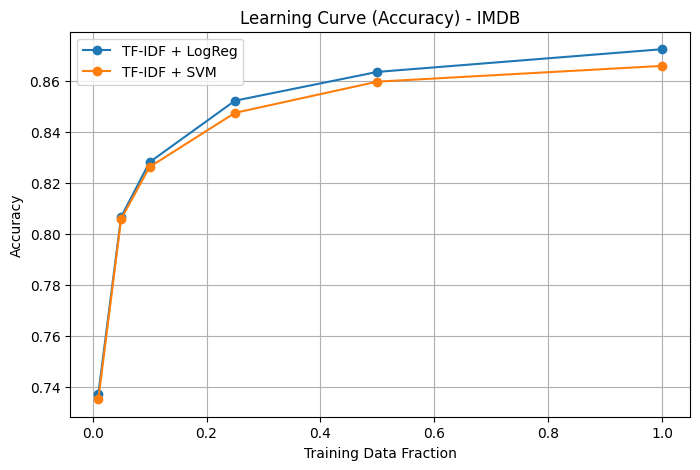

In [44]:
plt.figure(figsize=(8, 5))

for model_name in summary_df["model"].unique():
    temp = summary_df[summary_df["model"] == model_name].sort_values("fraction")
    plt.plot(temp["fraction"], temp["accuracy_mean"], marker="o", label=model_name)

plt.xlabel("Training Data Fraction")
plt.ylabel("Accuracy")
plt.title(f"Learning Curve (Accuracy) - {dataset_name}")
plt.legend()
plt.grid(True)
plt.show()

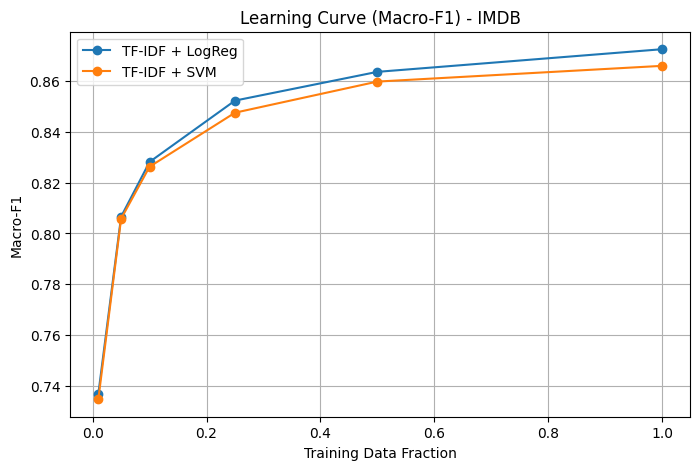

In [45]:
plt.figure(figsize=(8, 5))

for model_name in summary_df["model"].unique():
    temp = summary_df[summary_df["model"] == model_name].sort_values("fraction")
    plt.plot(temp["fraction"], temp["macro_f1_mean"], marker="o", label=model_name)

plt.xlabel("Training Data Fraction")
plt.ylabel("Macro-F1")
plt.title(f"Learning Curve (Macro-F1) - {dataset_name}")
plt.legend()
plt.grid(True)
plt.show()

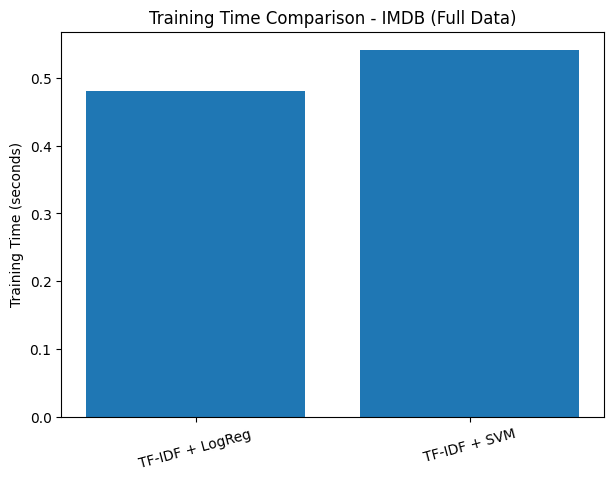

In [46]:
time_plot_df = summary_df[summary_df["fraction"] == 1.0].copy()

plt.figure(figsize=(7, 5))
plt.bar(time_plot_df["model"], time_plot_df["train_time_mean"])
plt.ylabel("Training Time (seconds)")
plt.title(f"Training Time Comparison - {dataset_name} (Full Data)")
plt.xticks(rotation=15)
plt.show()

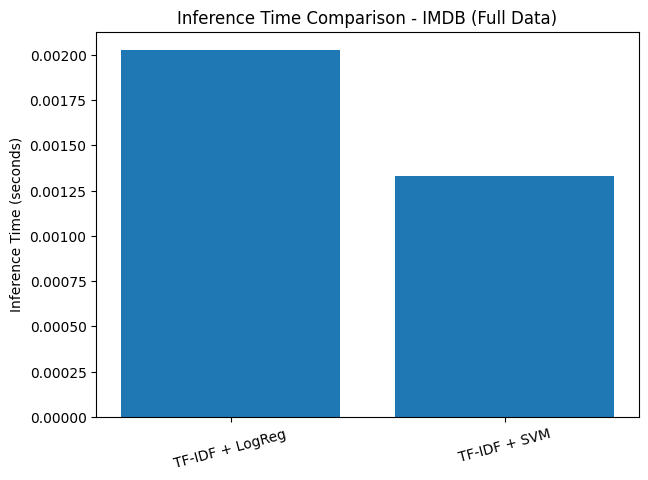

In [47]:
plt.figure(figsize=(7, 5))
plt.bar(time_plot_df["model"], time_plot_df["infer_time_mean"])
plt.ylabel("Inference Time (seconds)")
plt.title(f"Inference Time Comparison - {dataset_name} (Full Data)")
plt.xticks(rotation=15)
plt.show()

In [49]:
per_class_summary = (
    per_class_df.groupby(["dataset", "model", "class", "fraction"])
    .agg(mean_f1=("f1", "mean"))
    .reset_index()
)

full_data_per_class = per_class_summary[per_class_summary["fraction"] == 1.0]

best_worst_list = []
for (dataset, model), group in full_data_per_class.groupby(["dataset", "model"]):
    best_row = group.loc[group["mean_f1"].idxmax()]
    worst_row = group.loc[group["mean_f1"].idxmin()]

    best_worst_list.append({
        "dataset": dataset,
        "model": model,
        "best_class": best_row["class"],
        "best_class_f1": best_row["mean_f1"],
        "worst_class": worst_row["class"],
        "worst_class_f1": worst_row["mean_f1"]
    })

best_worst_df = pd.DataFrame(best_worst_list)
best_worst_df.to_csv(f"{safe_name}_best_worst_class.csv", index=False)
best_worst_df

,dataset,model,best_class,best_class_f1,worst_class,worst_class_f1
0,IMDB,TF-IDF + LogReg,1,0.873026,0,0.871767
1,IMDB,TF-IDF + SVM,1,0.866684,0,0.865039


In [50]:
focus_errors_logreg = error_df[
    (error_df["model"] == "TF-IDF + LogReg") &
    (error_df["fraction"] == 1.0) &
    (error_df["seed"] == 42)
].copy()

focus_errors_logreg = focus_errors_logreg.head(30)
focus_errors_logreg.to_csv(f"{safe_name}_logreg_top30_errors.csv", index=False)

focus_errors_logreg[["text", "label", "pred_label"]]

,text,label,pred_label
0,I thought this was one of the most depressing ...,0,1
1,"Guys, what can I tell you? I'm Bulgarian. I ca...",0,1
2,Telling the story wouldn't be the point at all...,1,0
3,The brief existence of The Sex Pistols and the...,0,1
4,It would be quite easy to make this movie soun...,0,1
5,The NYT review says that Sigourney Weaver's ch...,1,0
6,...but the general moviegoer's mileage may var...,1,0
7,"Why I disliked the movie, apart from the sheer...",0,1
8,"Lillian Hellman's play, adapted by Dashiell Ha...",0,1
9,"Contrary to another reviewer, I think that thi...",0,1


In [51]:
focus_errors_svm = error_df[
    (error_df["model"] == "TF-IDF + SVM") &
    (error_df["fraction"] == 1.0) &
    (error_df["seed"] == 42)
].copy()

focus_errors_svm = focus_errors_svm.head(30)
focus_errors_svm.to_csv(f"{safe_name}_svm_top30_errors.csv", index=False)

focus_errors_svm[["text", "label", "pred_label"]]

,text,label,pred_label
957,I thought this was one of the most depressing ...,0,1
958,"Guys, what can I tell you? I'm Bulgarian. I ca...",0,1
959,Telling the story wouldn't be the point at all...,1,0
960,The brief existence of The Sex Pistols and the...,0,1
961,It would be quite easy to make this movie soun...,0,1
962,The NYT review says that Sigourney Weaver's ch...,1,0
963,...but the general moviegoer's mileage may var...,1,0
964,Been lurking for a couple of years or so. I ha...,0,1
965,Whoever likened this one to RAIDERS OF THE LOS...,0,1
966,"Why I disliked the movie, apart from the sheer...",0,1


In [52]:
full_data_results = results_df[results_df["fraction"] == 1.0].copy()
full_data_results = full_data_results.sort_values(["model", "seed"]).reset_index(drop=True)

full_data_results

,dataset,model,fraction,seed,accuracy,macro_f1,train_time,infer_time,best_C,best_max_features
0,IMDB,TF-IDF + LogReg,1.0,42,0.872400,0.872397,0.461442,0.001997,10,50000
1,IMDB,TF-IDF + LogReg,1.0,123,0.872400,0.872397,0.459854,0.001996,10,50000
2,IMDB,TF-IDF + LogReg,1.0,456,0.872400,0.872397,0.520450,0.002088,10,50000
3,IMDB,TF-IDF + SVM,1.0,42,0.865867,0.865862,0.478492,0.001000,1,50000
4,IMDB,TF-IDF + SVM,1.0,123,0.865867,0.865862,0.470797,0.001984,1,50000
5,IMDB,TF-IDF + SVM,1.0,456,0.865867,0.865862,0.673817,0.001002,1,50000
